# Listening patterns: clustering for recommendations

<div class="alert alert-block alert-success">
<h2>Sobre este notebook (🇪🇸​):</h2>
<hr>
El objetivo de este notebook es <strong>descubrir patrones ocultos en datos no etiquetados de escucha musical a través de técnicas de aprendizaje no supervisado</strong>. Originalmente se desarrolló como parte del máster en ciencia de datos impartido por la UOC, con algunos cambios siendo a posteriori, por lo que solo se encuentra en español.
<hr>
El dataset utilizado es un conjunto real de sesiones de escucha de música de 1000 usuarios de LastFM, cuyo objetivo es únicamente el estudio de las diferentes técnicas exploradas en este proyecto, de las cuales las más relevantes podrían considerarse:
<ol>
<li>Co-ocurrencia: para representar relaciones entre canciones/artistas en sesiones de usuario</li>
<li>LDA (Latent Dirichlet Allocation): como método probabilístico de proyección y clustering</li>
<li>ALS (Alternating Least Squares): para factorización de matrices y recomendaciones</li>
</ol>
<hr>
En conclusión, este notebook es una introducción práctica al uso de técnicas de reducción dimensional y agrupamiento en datos de comportamiento musical, y es útil para comprender cómo descubrir estructuras latentes sin etiquetas, sin embargo, <strong>se trata con escasa profundidad el análisis de la calidad de los clusters y la interpretabilidad de las proyecciones, y no se tratan aspectos como la evaluación cuantitativa de las recomendaciones o la validación de los patrones descubiertos</strong>, por lo que no se debe entender este notebook como un sistema de recomendación end-to-end.
&nbsp;
</div>

<!-- -->
<div class="alert alert-block alert-success">
<h2>About this notebook (🇬🇧):</h2>
<hr>
The goal of this notebook is to <strong>uncover hidden patterns in unlabeled music-listening data using unsupervised learning techniques</strong>. It was originally developed as part of the Data Science Master’s program at the UOC, with some modifications made afterwards, which is why it is available only in Spanish.
<hr>
The dataset used consists of real music-listening sessions from 1,000 LastFM users. Its purpose is solely to study the different techniques explored in this project, among which the most relevant are:
<ol>
<li>Co-occurrence: to represent relationships between songs/artists within user sessions</li>
<li>LDA (Latent Dirichlet Allocation): as a probabilistic projection and clustering method</li>
<li>ALS (Alternating Least Squares): for matrix factorization and recommendations</li>
</ol>
<hr>
In conclusion, this notebook is a practical introduction to the use of dimensionality-reduction and clustering techniques applied to musical-behavior data, and it is useful for understanding how to discover latent structures without labels. However, <strong>it provides only a shallow analysis of cluster quality and projection interpretability, and does not include aspects such as quantitative evaluation of recommendations or validation of the discovered patterns</strong>. For these reasons, this notebook should not be understood as an end-to-end recommendation system.
&nbsp;
</div>


In [1]:
from collections import defaultdict
from itertools import permutations
import pickle
import random
import warnings

from adjustText import adjust_text
from implicit.als import AlternatingLeastSquares
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.decomposition import LatentDirichletAllocation
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset
import tqdm
import umap

# Utilizar la semilla hace que la ejecución sea algo más lenta (por num. workers)
seed = 100

warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.utils.deprecation")

plt.rcParams['font.family'] = 'Arial Unicode MS'
%matplotlib inline

## Preparación de los datos

<!-- -->
<div class="alert alert-block alert-info">
<h4>Preparación de los datos: </h4>
    Trabajaremos con una versión del dataset LastFM 1K, un conjunto real de datos recopilado desde la plataforma musical Last.fm. Contiene el historial de escucha de aproximadamente 1.000 usuarios, donde se registran las canciones que cada usuario ha escuchado, con información sobre el usuario, la fecha de reproducción, el artista y la canción. En primer lugar cargaremos la base de datos y realizaremos una primera exploración básica.
</div>

In [2]:
df = pd.read_csv("./music.tsv/music.tsv", sep="\t", header=0)

In [3]:
df.sample(5)

,user_id,artist,track
3385629,user_000750,Morgentot,Layla
892673,user_000194,Afi,Soap-Box Derby
3650017,user_000792,Sex In Dallas,Everybody Deserves To Be Fucked
2568574,user_000584,Air,Afternoon Sister
2127432,user_000477,Edie Brickell & New Bohemians,Circle


<div class="alert alert-block alert-info">
<h4>Eliminación de duplicados: </h4>
    Vamos a eliminar aquellos registros que solo difieran en el timestamp (un usuario que escuche la misma canción múltiples veces), dejando una sola combinación de `usuario`, `artista` y `canción`.
</div>

In [4]:
# Parece que no hay registros duplicados
# Aun así realizamos la limpieza
print(f"Número de registros duplicados: {df.duplicated(subset=["user_id", "artist", "track"]).sum()}")

df.drop_duplicates(subset=["user_id", "artist", "track"], inplace = True)

print(f"Número de registros duplicados tras la limpieza: {df.duplicated(subset=["user_id", "artist", "track"]).sum()}")

Número de registros duplicados: 0
Número de registros duplicados tras la limpieza: 0


<div class="alert alert-block alert-info">
<h4>Filtrado de registros: </h4>
Para reducir el tamaño del dataset y centrarnos en las canciones con mayor relevancia, eliminaremos aquellas que hayan tenido muy poca repercusión (menos de 20 escuchas).
</div>

In [5]:
# Asumiré que dos canciones del mismo título son diferentes si es de otro artista
print(f"Número de canciones únicas: {df[["artist", "track"]].drop_duplicates().shape[0]}")

listeners = df.groupby(["artist", "track"])["user_id"].nunique()
tracks = listeners[listeners > 20].index
df = df[df.set_index(["artist", "track"]).index.isin(tracks)].reset_index(drop=True)

print(f"Número de canciones relevantes: {df[['artist', 'track']].drop_duplicates().shape[0]}")

Número de canciones únicas: 1498718
Número de canciones relevantes: 32790


<div class="alert alert-block alert-info">
<h4>Identificación de artistas y canciones únicos:</h4>
Generaremos una serie de valores únicos para las columnas de usuarios, canciones y artistas. A partir de estas, crearemos cuatro diccionarios que nos permitirán mapear entre nombres (strings) e índices (enteros correlativos comenzando desde el 0) y viceversa. Esto será útil para representar numéricamente el dataset.
</div>

In [6]:
# 1. Series para cada variable
unique_users = df["user_id"].drop_duplicates().reset_index(drop=True)
unique_artists = df["artist"].drop_duplicates().reset_index(drop=True)
unique_songs = df[["artist", "track"]].drop_duplicates().apply(lambda x: f"{x['artist']} - {x['track']}", axis=1).reset_index(drop=True)

# 2. Creamos diccionarios para mapear las variables a sus índices y viceversa
user_to_idx = {user: idx for idx, user in enumerate(unique_users)}
idx_to_user = {idx: user for idx, user in enumerate(unique_users)}

artist_to_idx = {artist: idx for idx, artist in enumerate(unique_artists)}
idx_to_artist = {idx: artist for idx, artist in enumerate(unique_artists)}

song_to_idx = {song: idx for idx, song in enumerate(unique_songs)}
idx_to_song = {idx: song for idx, song in enumerate(unique_songs)}

print(unique_users.head(), "\n")
print(unique_artists.head(), "\n")
print(unique_songs.head(), "\n")

0    user_000001
1    user_000002
2    user_000003
3    user_000004
4    user_000005
Name: user_id, dtype: object 

0             Minus 8
1               4Hero
2            Röyksopp
3    Bugge Wesseltoft
4         Fleet Foxes
Name: artist, dtype: object 

0             Minus 8 - Elysian Fields
1                4Hero - Morning Child
2    Röyksopp - The Girl And The Robot
3                Röyksopp - Vision One
4             Röyksopp - Happy Up Here
dtype: object 



Comprobaciones sobre los datos:

In [7]:
assert len(unique_users) == 991 and unique_users.index.min() == 0 and unique_users.index.max() == 990, '# of users does not match!'
assert len(unique_artists) == 2821 and unique_artists.index.min() == 0 and unique_artists.index.max() == 2820, '# of artists does not match!'
assert len(unique_songs) == 32790 and unique_songs.index.min() == 0 and unique_songs.index.max() == 32789, '# of songs does not match!'

<div class="alert alert-block alert-info">
<h4>Matrices de coocurrencia: </h4>
Vamos a representar las interacciones entre usuarios y contenido musical en formato matricial, lo que nos permitirá trabajar con los datos de forma vectorial en los siguientes bloques, una que represente si un usuario a escuchado al menos una vez a un artista y otra de igual forma con canciones.
    Como estas matrices serán muy dispersas usaremos el formato CSR (Compressed Sparse Row), que almacena solo los valores distintos de cero junto con sus posiciones, lo que permite ahorrar memoria y acelerar algunas operaciones.
</div>

In [8]:
# Para obtener una matriz usuario-canción necesitamos 

# Mapeamos los strings a índices numéricos para todas las variables
# Esto lo hacemos ya que csr_matrix() no acepta strings
df["user_idx"] = df["user_id"].map(user_to_idx)
df["artist_idx"] = df["artist"].map(artist_to_idx)
df["song_id"] = df.apply(lambda row: f"{row['artist']} - {row['track']}", axis=1)
df["song_idx"] = df["song_id"].map(song_to_idx)

rows_artist = df["user_idx"].values
cols_artist = df["artist_idx"].values
data_artist = np.ones(len(df), dtype=int)

user_artist_matrix = csr_matrix(
    (data_artist, (rows_artist, cols_artist)),
    shape=(len(user_to_idx), len(artist_to_idx))
)

# Eliminamos repeticiones (una escucha cuenta como 1)
user_artist_matrix.data = np.ones_like(user_artist_matrix.data)
user_artist_matrix.eliminate_zeros()

rows_song = df["user_idx"].values
cols_song = df["song_idx"].values
data_song = np.ones(len(df), dtype=int)

user_song_matrix = csr_matrix(
    (data_song, (rows_song, cols_song)),
    shape=(len(user_to_idx), len(song_to_idx))
)

user_song_matrix.data = np.ones_like(user_song_matrix.data)
user_song_matrix.eliminate_zeros()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Grado de dispersión:</strong> Para conocer el grado de dispersión que tiene la matriz podemos calcular la proporción de 1s con respecto al total de elementos de la matriz: user_song_matrix.
</div>

In [9]:
total_elem = user_song_matrix.shape[0] * user_song_matrix.shape[1]
ones = user_song_matrix.nnz  # .nnz = número de elementos no nulos

ones_rate = ones / total_elem

print(f"Proporción de 1s en user_song_matrix: {ones_rate:.6f}")

Proporción de 1s en user_song_matrix: 0.046187


## Exploración de patrones

<div class="alert alert-block alert-info">
<h4>Exploración visual de patrones de escucha: </h4>
Al ser matrices bastante extensas, tendremos que aplicar una técnica de reducción de dimensionalidad que nos permita mantener la estructura del espacio original y proyectarlo en 2D. Algunas de las técnicas más comunes para este tipo de tarea son: *PCA (Análisis de Componentes Principales)*, *t-SNE (t-distributed Stochastic Neighbor Embedding)* o *UMAP (Uniform Manifold Approximation and Projection)*. De estas opciones UMAP será la más adecuada ya que permite mantener la estructura de los datos en conjuntos grandes con posibles escalados (https://umap-learn.readthedocs.io/en/latest/sparse.html).
</div>

C:\Users\Usuario\anaconda3\envs\env_uoc202402pec2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Usuario\anaconda3\envs\env_uoc202402pec2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


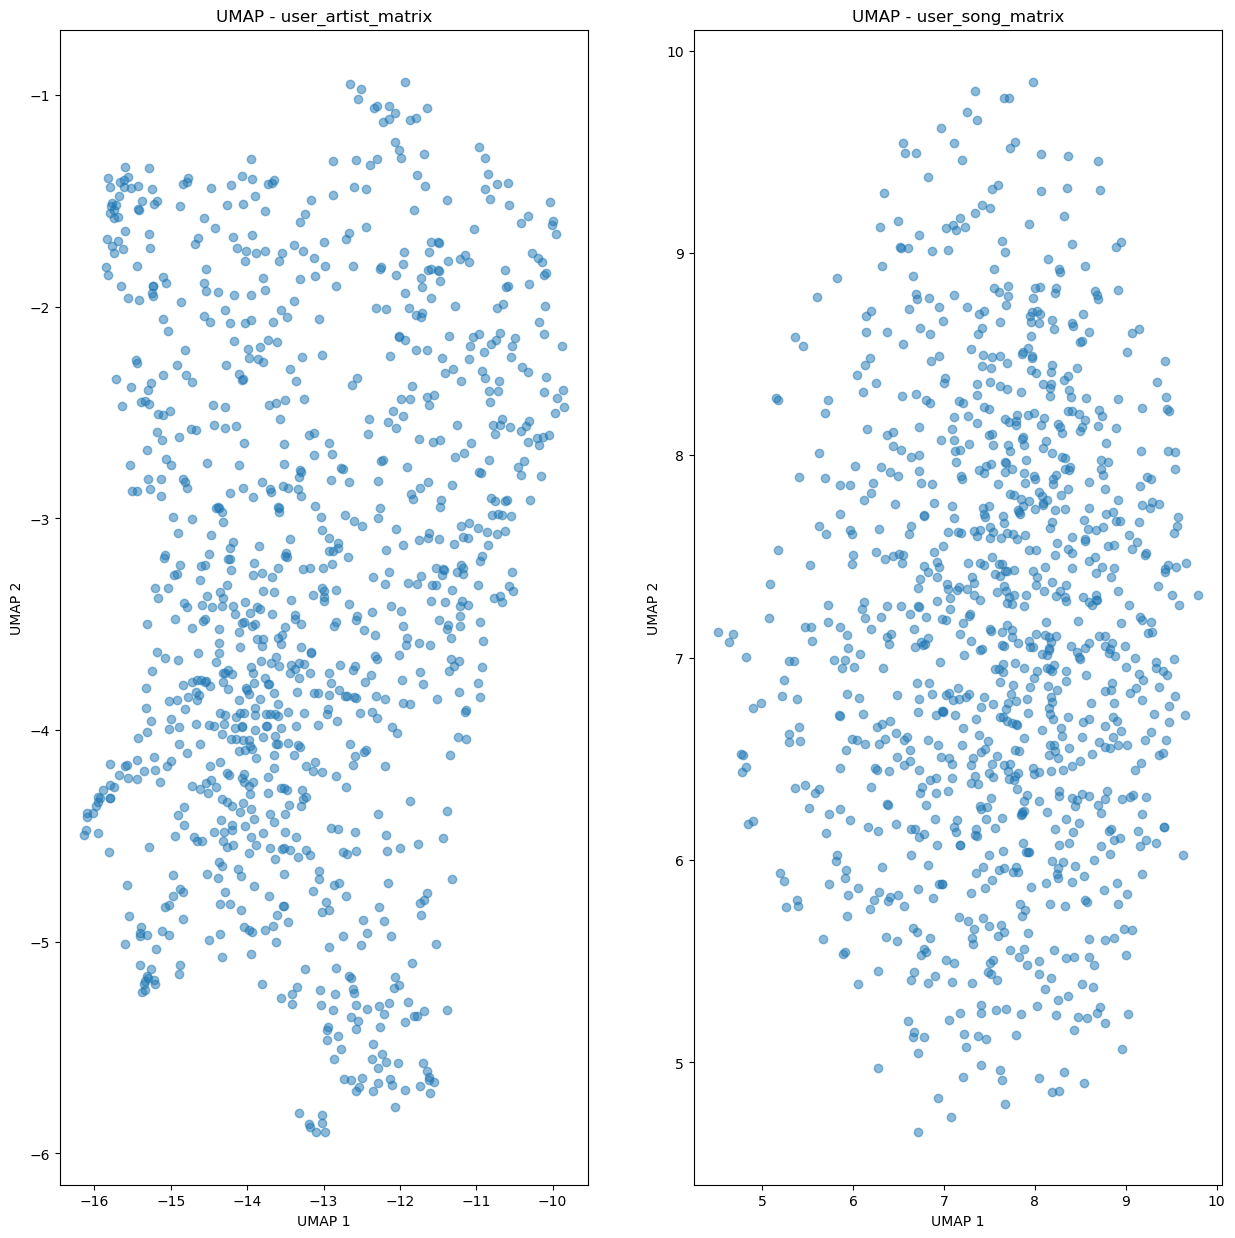

In [10]:
umap_artist = umap.UMAP(n_components=2, random_state=seed).fit_transform(user_artist_matrix)
umap_song = umap.UMAP(n_components=2, random_state=seed).fit_transform(user_song_matrix)

# Esto es solo para evitar los warnings de las fuentes
plt.rcParams["font.family"] = "DejaVu Sans"

fig, axes = plt.subplots(1, 2, figsize=(15, 15))

# user_artist_matrix
axes[0].scatter(umap_artist[:, 0], umap_artist[:, 1], alpha=0.5)
axes[0].set_title("UMAP - user_artist_matrix")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

# user_song_matrix
axes[1].scatter(umap_song[:, 0], umap_song[:, 1], alpha=0.5)
axes[1].set_title("UMAP - user_song_matrix")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

plt.show()


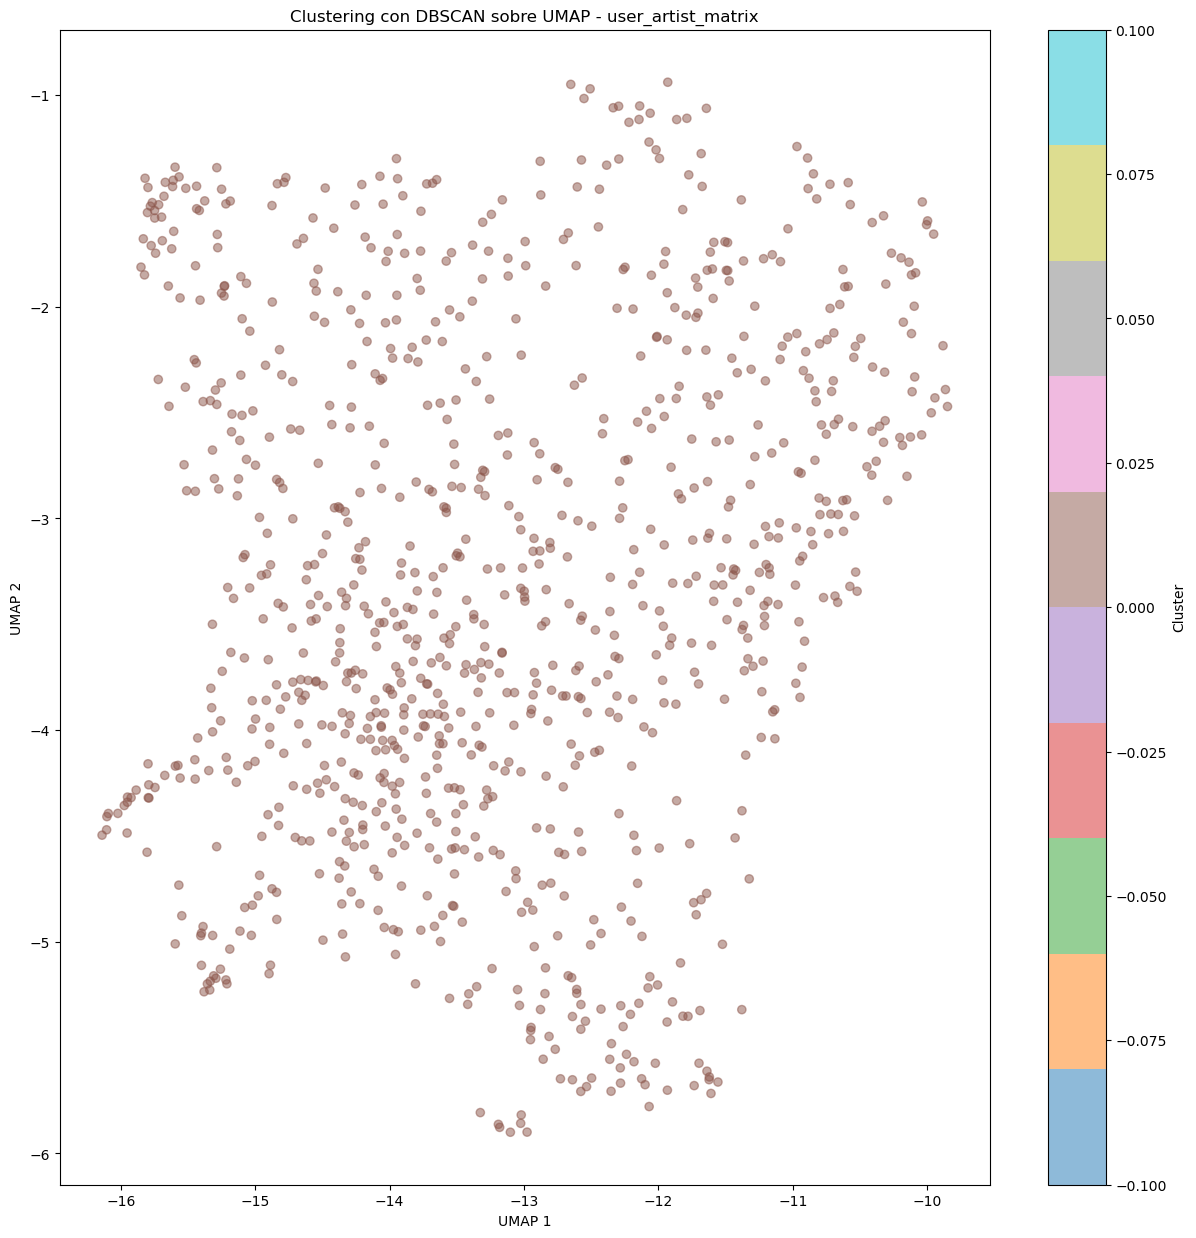

In [11]:
# No veo ninguna estructura clara, pero para encontrar clusters utilizaré DBSCAN
from sklearn.cluster import DBSCAN

clustering = DBSCAN(eps=0.7, min_samples=10).fit(umap_artist)
labels = clustering.labels_

plt.figure(figsize=(15, 15))
scatter = plt.scatter(umap_artist[:, 0], umap_artist[:, 1], c=labels, cmap="tab10", alpha=0.5)
plt.title("Clustering con DBSCAN sobre UMAP - user_artist_matrix")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

# No se aprecia ningún clusters


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Transposición de la matriz:</strong> En muchos problemas de “usuarios × ítems” (filas = usuarios, columnas = canciones/artistas) lo que solemos clusterizar primero son usuarios (filas).
Si trasponemos la matriz (filas = ítems, columnas = usuarios) podemos clusterizar ítems (canciones, artistas). 
    
Una vez aplicamos la transposición a la matriz, las representaciones de artistas y canciones según el consumo de los usuarios parecen estar más agrupadas, y tienen una estructura más difinida. Las zonas podrían representar géneros o agrupaciones de usuarios con gustos similares en el caso de la representación de los artistas.
Para la gráfica de canciones vemos que es mucho más densa en el centro, lo que puede indicar que muchas canciones probablemente las más populares son escuchadas por un conjunto grande y común de usuarios, mientras que otras son menos conocidas.
</div>

C:\Users\Usuario\anaconda3\envs\env_uoc202402pec2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


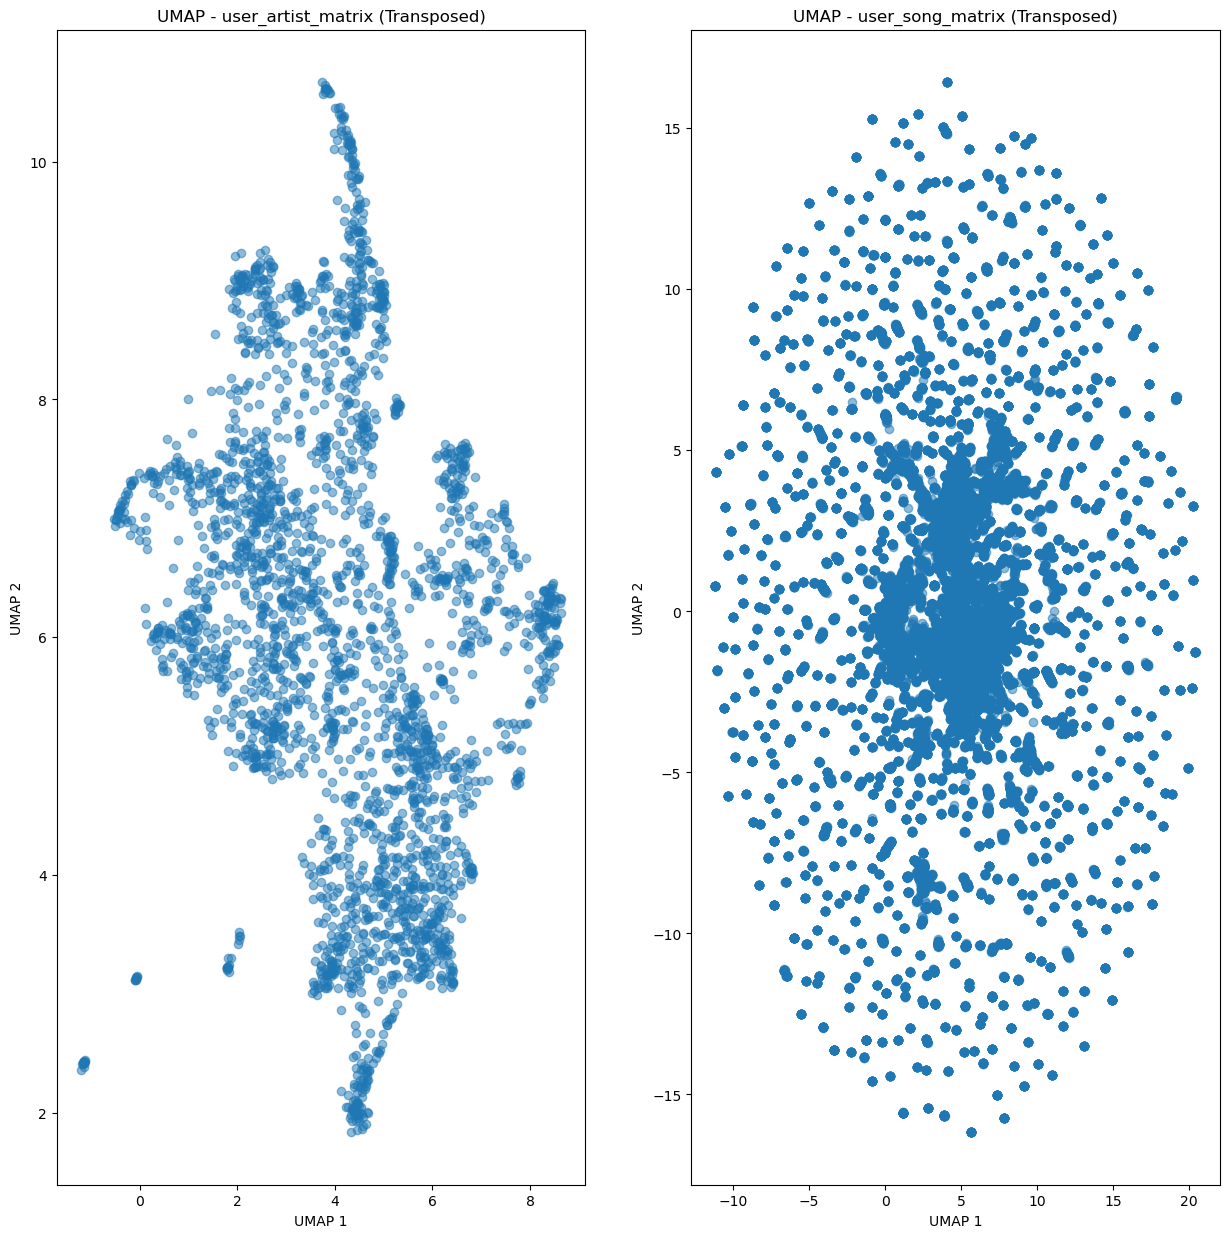

In [12]:
user_artist_matrix_tp = user_artist_matrix.T
user_song_matrix_tp = user_song_matrix.T

umap_artist_tp = umap.UMAP(n_components=2, random_state=seed).fit_transform(user_artist_matrix_tp)
umap_song_tp = umap.UMAP(n_components=2, random_state=seed).fit_transform(user_song_matrix_tp)

# Esto es solo para evitar los warnings de las fuentes
plt.rcParams["font.family"] = "DejaVu Sans"

fig, axes = plt.subplots(1, 2, figsize=(15, 15))

# user_artist_matrix
axes[0].scatter(umap_artist_tp[:, 0], umap_artist_tp[:, 1], alpha=0.5)
axes[0].set_title("UMAP - user_artist_matrix (Transposed)")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

# user_song_matrix
axes[1].scatter(umap_song_tp[:, 0], umap_song_tp[:, 1], alpha=0.5)
axes[1].set_title("UMAP - user_song_matrix (Transposed)")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Aplicando DBSCAN:</strong> DBSCAN agrupa puntos que están densamente conectados y marca como “ruido” los que quedan aislados, lo que es útil cuando tenemos clusters de forma arbitraria.
</div>

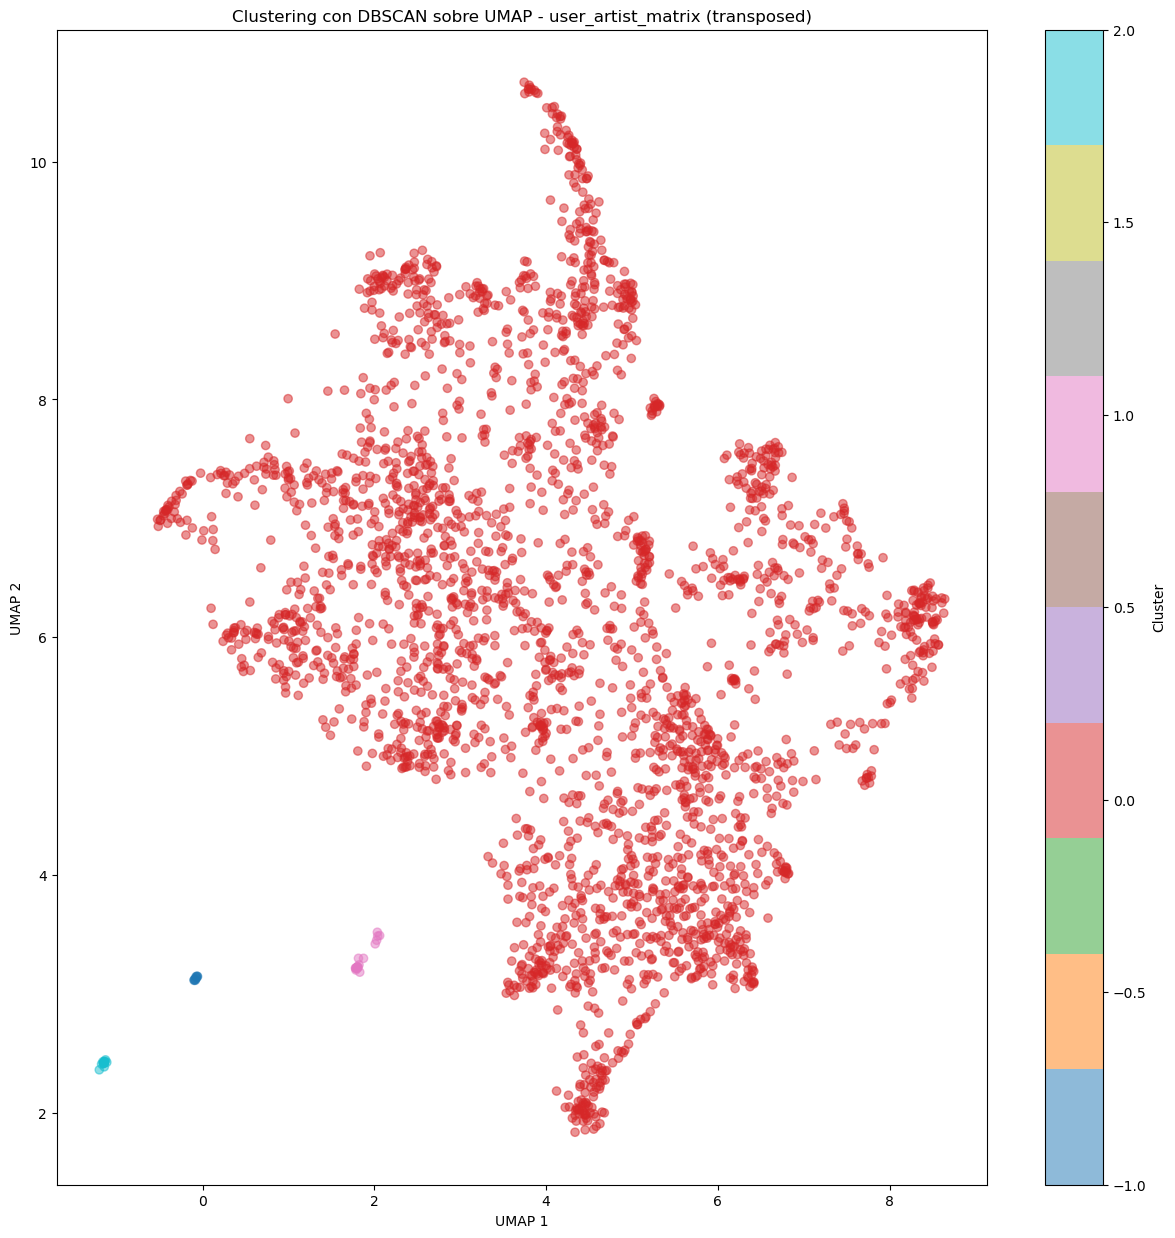

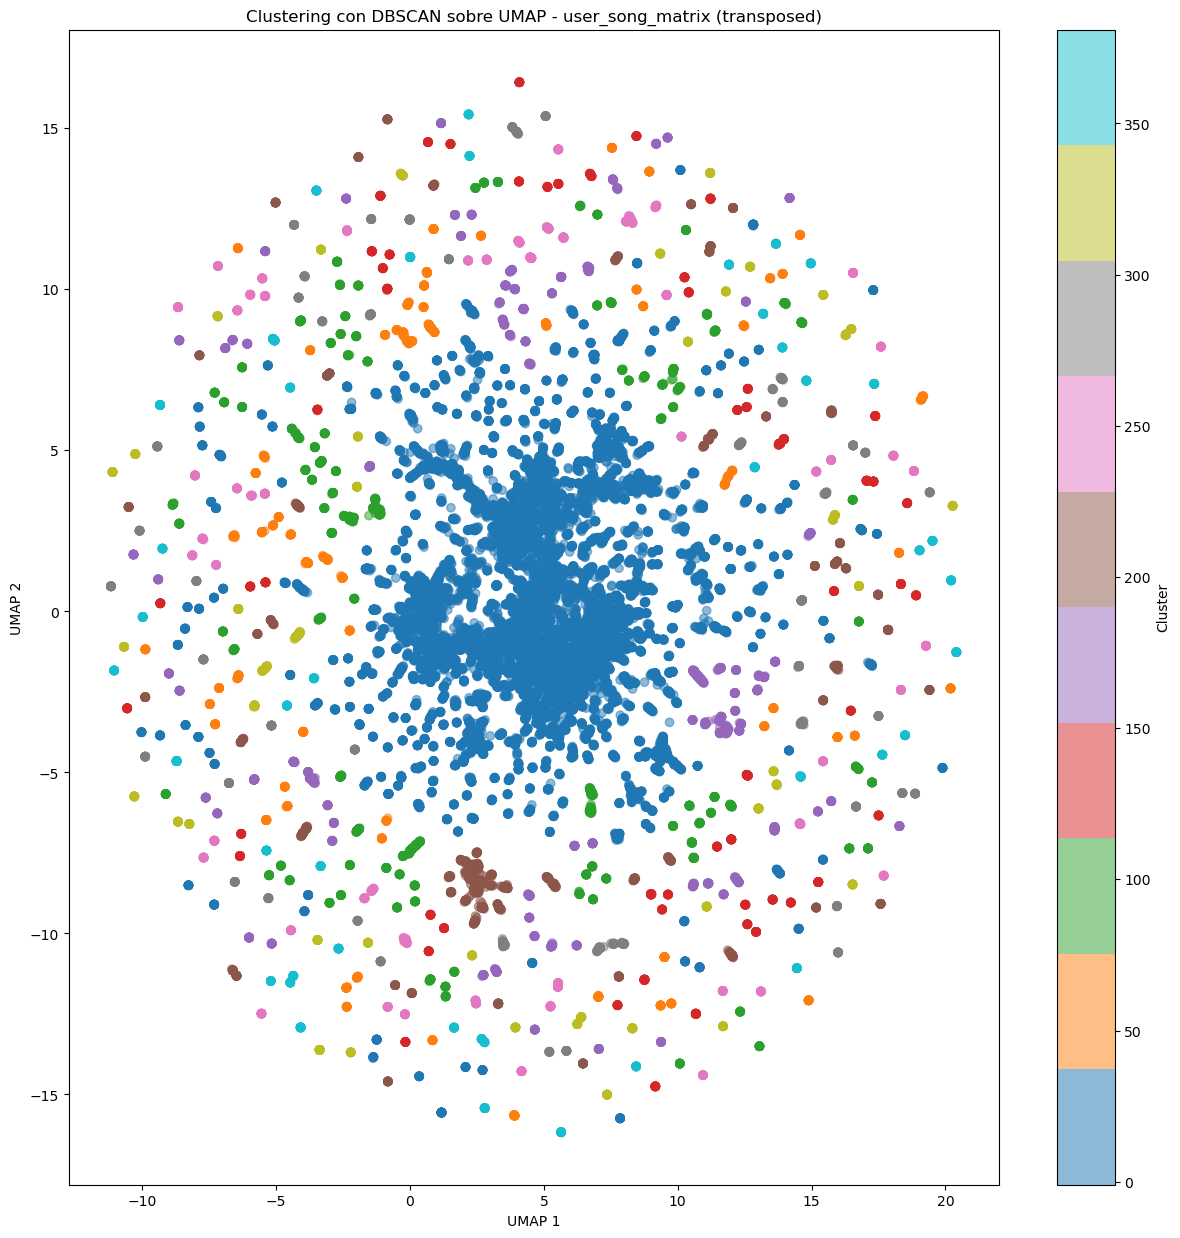

In [13]:
from sklearn.cluster import DBSCAN

clustering = DBSCAN(eps=0.7, min_samples=10).fit(umap_artist_tp)
labels = clustering.labels_

plt.figure(figsize=(15, 15))
scatter = plt.scatter(umap_artist_tp[:, 0], umap_artist_tp[:, 1], c=labels, cmap="tab10", alpha=0.5)
plt.title("Clustering con DBSCAN sobre UMAP - user_artist_matrix (transposed)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

clustering = DBSCAN(eps=0.7, min_samples=10).fit(umap_song_tp)
labels = clustering.labels_

plt.figure(figsize=(15, 15))
scatter = plt.scatter(umap_song_tp[:, 0], umap_song_tp[:, 1], c=labels, cmap="tab10", alpha=0.5)
plt.title("Clustering con DBSCAN sobre UMAP - user_song_matrix (transposed)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

## Proyección del gusto musical con LDA 

<div class="alert alert-block alert-info">
<h4>Búsqueda de temas latentes: </h4>
Vamos a aplicar LDA (Latent Dirichlet Allocation) para descubrir temas musicales latentes que expliquen cómo se mezclan los gustos de cada usuario y, de paso, obtener proyecciones tanto de usuarios como de artistas que podremis usar después para visualizar clusters o alimentar recomendadores.
LDA:
    Es un modelo probabilístico que trata cada usuario como un “documento” y cada artista como una “palabra”.
Supone que hay K temas ocultos (ej. “Pop comercial”, “Rock clásico”, “Rap underground”…) y que:
<ol>
<li> cada usuario es una mezcla de esos temas (ej. 40 % Pop, 20 % Rock, …)</li>
<li> cada tema es una bolsa de artistas con ciertas probabilidades.</li>
Devuelve matrices interpretables:
<li> user_topic (probabilidad de cada tema por usuario)</li>
<li> topic_artist (probabilidad de cada artista dentro del tema)</li>
</ol>
</div>
</div>

In [14]:
# Para comparar varias agrupaciones he creado una función que prueba una lista de parámetros
def test_artist_clusters(topics_list):
    for n_topics in topics_list:
        # Aplicamos LDA y mostramos el resultado para el número de clusters dado
        lda = LatentDirichletAllocation(n_components=n_topics, random_state=seed)
        user_topic_distribution = lda.fit_transform(user_artist_matrix)      # matriz n_users x n_topics
        topic_artist_distribution = lda.components_                          # matriz n_topics x n_artists
        
        top_artistas_por_tema = []
        
        for topic_idx, topic in enumerate(topic_artist_distribution):
            top_indices = topic.argsort()[::-1][:15]
            top_artists = [idx_to_artist[i] for i in top_indices]
            top_artistas_por_tema.append((f"Tema {topic_idx}", top_artists))
    
        df_temas = pd.DataFrame({tema: artistas for tema, artistas in top_artistas_por_tema})
        print(df_temas)

#test_artist_clusters([8, 10, 12, 15, 20])

# De la anterior lista de clusters, creo que el mejor agrupamiento de artistas por género se da en 12 clusters:
# 0 -> indie, 1 -> pop punk, 2 -> rock clásico, 3 -> electrónica, 4 -> indie rock/alternativo, 5 -> punk, 6 -> pop/rock alternativo
# 7 -> heavy metal clásico, 8 -> brit-indie, 9 y 10 -> electropop/dance, 11 -> synth 80s 
# Hay solapamientos y agrupaciones lejanas, pero he considerado que era la mejor opción, por lo tanto:

test_artist_clusters([12])

                               Tema 0                    Tema 1  \
0                   The Moldy Peaches               The Killers   
1                              M.I.A.        Panic At The Disco   
2                               Kelis                 Blink-182   
3                            Ladytron              Fall Out Boy   
4                           Cat Power  The All-American Rejects   
5                              Mogwai       My Chemical Romance   
6                      Gnarls Barkley                  Coldplay   
7                         Andrew Bird             Nelly Furtado   
8                     Type O Negative         Justin Timberlake   
9   Suburban Kids With Biblical Names                  Maroon 5   
10          Michael Cera & Ellen Page              Gwen Stefani   
11                    Gay Against You             Avril Lavigne   
12                       Kimya Dawson    Dashboard Confessional   
13                         The Zutons                   Rihann

<div class="alert alert-block alert-info">
<h4>Visualización de usuarios: </h4>
Visualizaremos los temas latentes encontrados, reduciendo antes la dimensionalidad con UMAP, representando a cada usuario con el color de su tema latente más relevante.
</div>

C:\Users\Usuario\anaconda3\envs\env_uoc202402pec2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


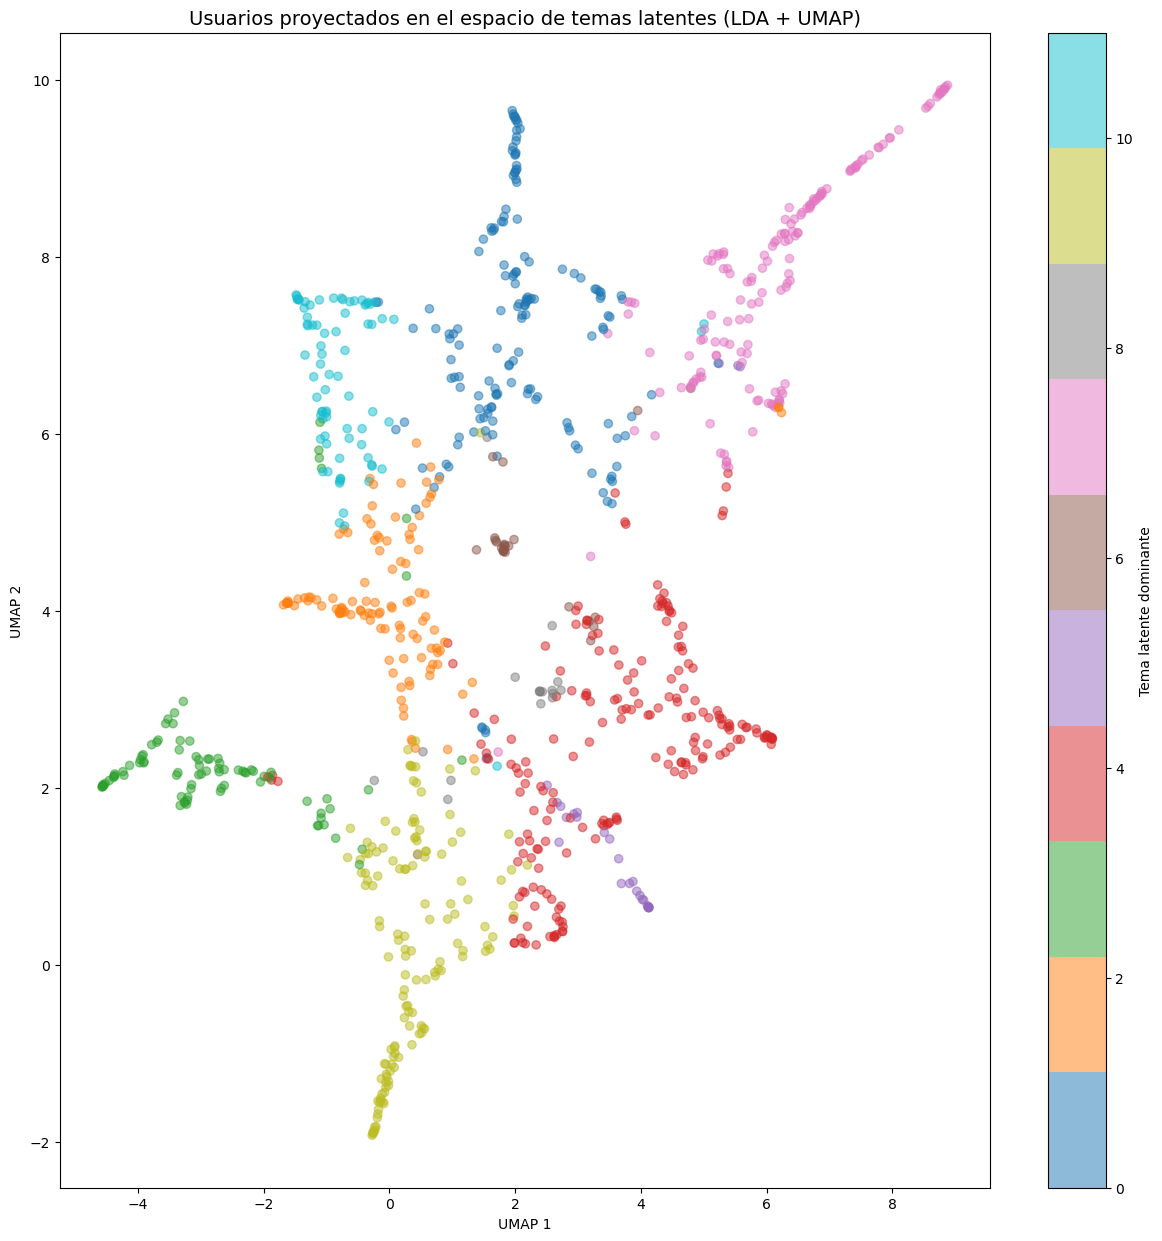

In [15]:
# Procedemos con 12 géneros o agrupaciones
lda = LatentDirichletAllocation(n_components=12, random_state=seed)
user_topic_distribution = lda.fit_transform(user_artist_matrix)

# Tema más dominante por usuario
user_dominant_topic = np.argmax(user_topic_distribution, axis=1)

# Reducimos a 2D con UMAP
user_topic_2d = umap.UMAP(n_components=2, random_state=seed).fit_transform(user_topic_distribution)

plt.figure(figsize=(15, 15))
scatter = plt.scatter(user_topic_2d[:, 0], user_topic_2d[:, 1], c=user_dominant_topic, cmap="tab10", alpha=0.5)
plt.title("Usuarios proyectados en el espacio de temas latentes (LDA + UMAP)", fontsize=14)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Tema latente dominante")
plt.show()

# Puede apreciarse claramente la diferenciación de gustos musicales de los usuarios
# El sistema capta muy bien las agrupaciones temáticas, considerando los usuarios con 
# un comporamiento mixto ya que casi siempre habrá solapes.

<div class="alert alert-block alert-info">
<h4>Visualización de artistas y canciones: </h4>
Visualizaremos con matplotlib la proyección de artistas y de canciones al espacio latente de la dimensión seleccionada anteriormente. Mostraremos aleatoriamente algunas etiquetas, ya que de lo contrario no sería visualizable.
</div>

C:\Users\Usuario\anaconda3\envs\env_uoc202402pec2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


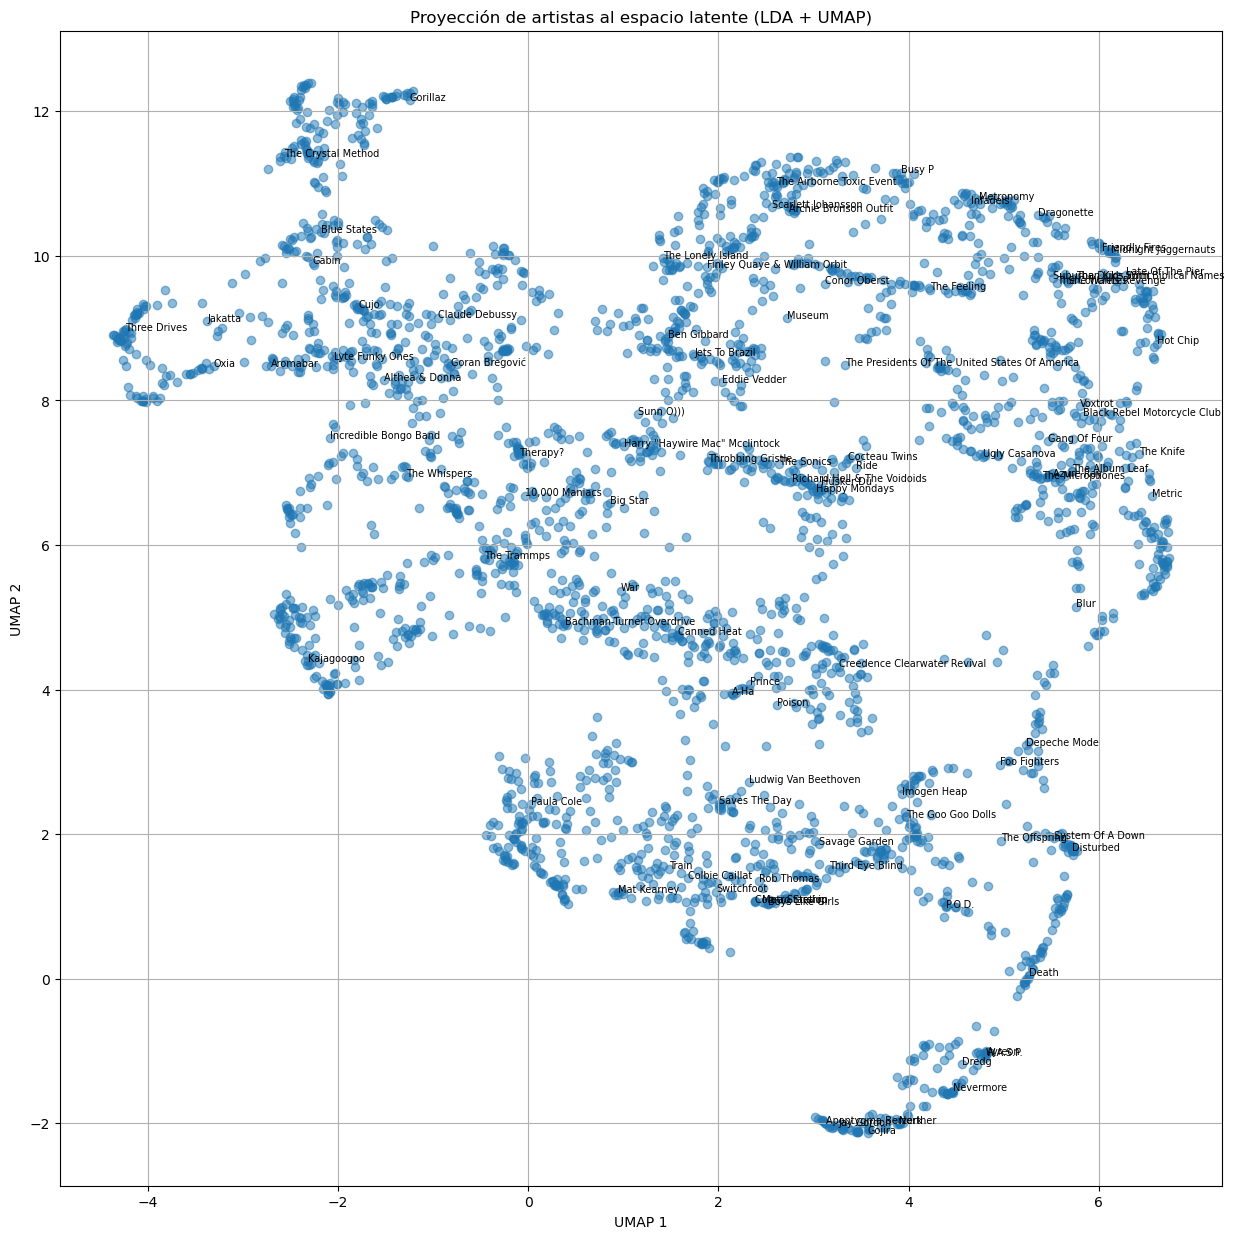

C:\Users\Usuario\anaconda3\envs\env_uoc202402pec2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


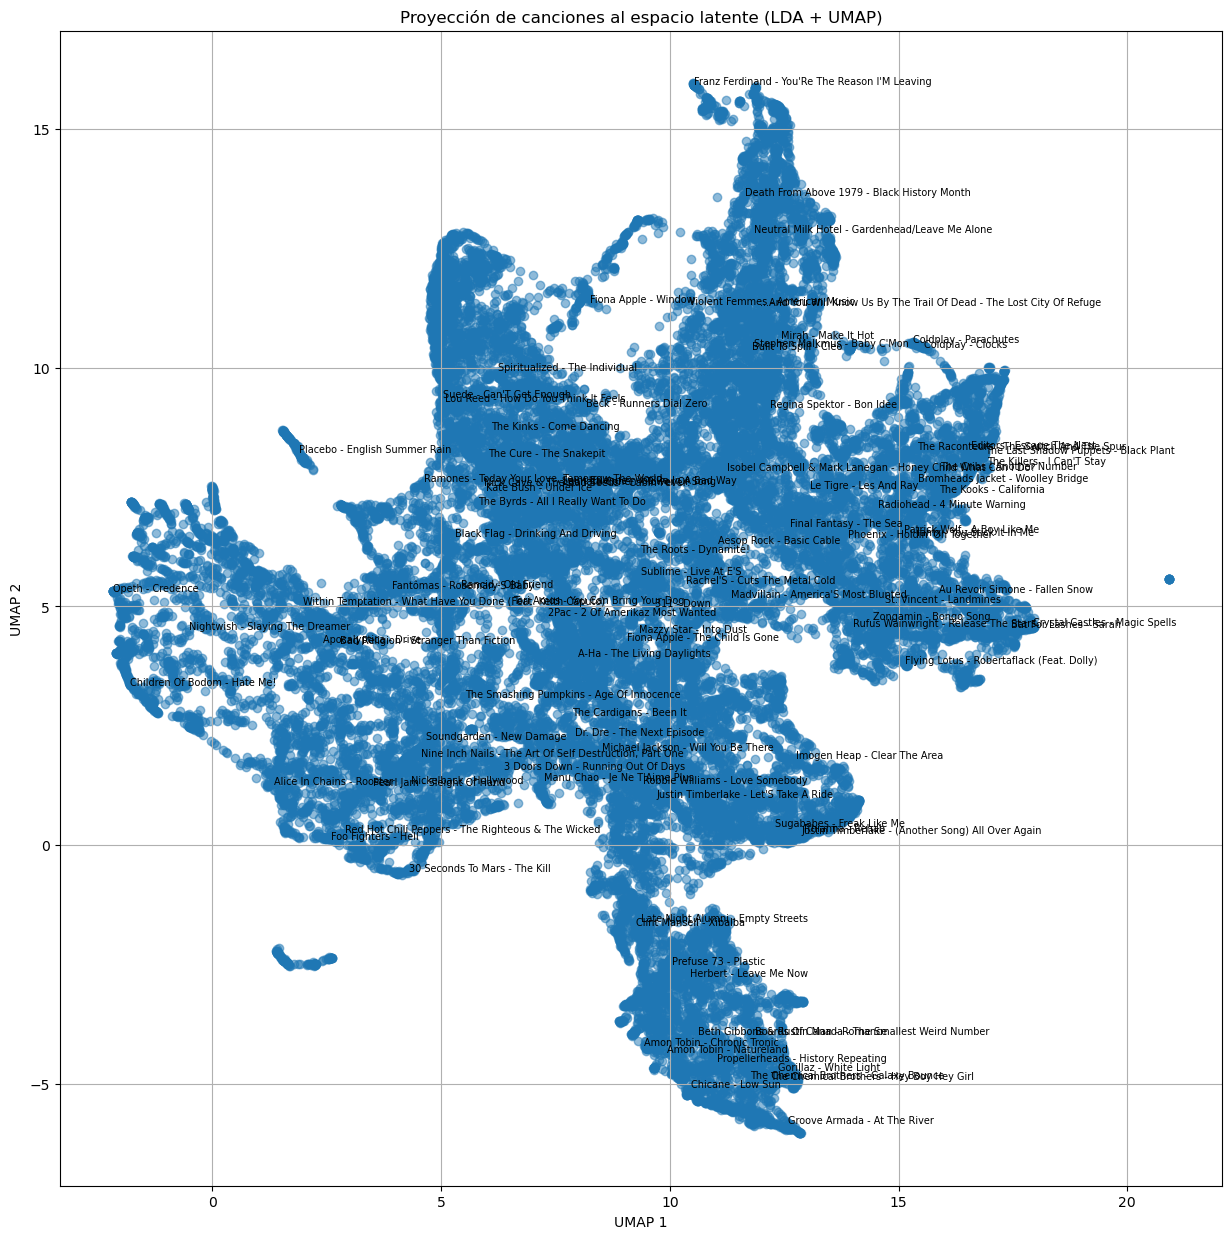

In [25]:
# Artistas

topic_artist_distribution = lda.components_.T  # Transpuesta -> shape: (n_artists, n_topics)

artist_2d = umap.UMAP(n_components=2, random_state=seed).fit_transform(topic_artist_distribution)

sample_artist_idx = random.sample(range(len(artist_2d)), 100)
sample_artist_labels = [idx_to_artist[i] for i in sample_artist_idx]

plt.figure(figsize=(15, 15))
plt.scatter(artist_2d[:, 0], artist_2d[:, 1], alpha=0.5, label="Artistas")
for i in sample_artist_idx:
    plt.text(artist_2d[i, 0], artist_2d[i, 1], idx_to_artist[i], fontsize=7)
plt.title("Proyección de artistas al espacio latente (LDA + UMAP)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.show()


# Canciones

lda_song = LatentDirichletAllocation(n_components=12, random_state=seed)
lda_song.fit(user_song_matrix)
topic_song_distribution = lda_song.components_.T  # (n_songs, n_topics)

song_2d = umap.UMAP(n_components=2, random_state=seed).fit_transform(topic_song_distribution)

sample_song_idx = random.sample(range(len(song_2d)), 100)
sample_song_labels = [idx_to_song[i] for i in sample_song_idx]

plt.figure(figsize=(15, 15))
plt.scatter(song_2d[:, 0], song_2d[:, 1], alpha=0.5, label="Canciones")
for i in sample_song_idx:
    plt.text(song_2d[i, 0], song_2d[i, 1], idx_to_song[i], fontsize=7)
plt.title("Proyección de canciones al espacio latente (LDA + UMAP)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> La matriz de canciones es más difusa y difícil de interpretar ya que hay mucha más cantidad de canciones únicas, además, dos canciones del mismo artista pueden no ser escuchadas por el mismo usuario y/o ser de géneros diferentes. Por otro lado la matriz de artistas es más interpretable y se aprecia mejor la estructura y la separación entre artistas de distintos estilos.
En el caso de las gráficas anteriores los puntos se basan en usuarios con escuchas similares, pero tiene mucho ruido ya que tiene menor organización. Al agrupar a los artistas por temas le damos estructura a la matriz de usuarios por sus patrones de escucha, por lo que las nuevas gráficas permiten observar los patrones de los usuarios.
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Un algoritmo de recomendación con LDA podría basarse, si tomamos la gráfica, en la distancia euclidea entre puntos según las canciones más escuchadas o vectores temáticos antes de aplicar umap, calculado en base a sus canciones más escuchadas, tras lo que se recomienda los temas más cercanos que aun no ha reproducido (o que haya reproducido muy pocas veces).
</div>

## Proyección del gusto musical con factorización de matrices

<div class="alert alert-block alert-info">
<h4> Proyectar para recomendar: factorización de matrices</h4>
Hasta ahora hemos usado coocurrencia y LDA para representar a los usuarios y detectar patrones de escucha. 
Pero, ¿y si existiera una proyección pensada específicamente para <strong>recomendar</strong>?  
Aquí entra en juego una nueva familia de métodos: <strong>factorización de matrices</strong>.
<br><br>
Estos métodos son de las herramientas más utilizadas en sistemas de recomendación (como Netflix o Spotify), porque permiten:
<ul>
<li><strong>Predecir qué canciones o artistas gustarán a cada usuario.</strong></li>
<li><strong>Reducir la dimensionalidad</strong> y representar usuarios e ítems en un <strong>mismo espacio vectorial</strong>.</li>
<li><strong>Aprender afinidades</strong>: la cercanía entre usuario y artista implica probabilidad de gusto.</li>
</ul>
Modelos conocidos:
<ul>
<li><strong>SVD</strong>: descompone la matriz en componentes ortogonales.</li>
<li><strong>NNMF</strong>: factores no negativos, más interpretables.</li>
<li><strong>ALS</strong>: muy usado con matrices dispersas.</li>
<li><strong>BPR</strong>: optimiza rankings en vez de puntuaciones.</li>
<li><strong>LightFM / DeepFM</strong>: modelos híbridos más complejos.</li>
</ul>
Aunque también reducen dimensionalidad, aquí la finalidad es <strong>reconstruir preferencias faltantes</strong>, no interpretar temas.  
En LDA proyectábamos sobre un espacio de temas explicativos; en factorización proyectamos sobre un espacio donde la <strong>cercanía implica afinidad</strong> y permite <strong>predecir lo que falta</strong>.
<br><br>
<img src="https://media.springernature.com/lw685/springer-static/image/chp%3A10.1007%2F978-3-030-03405-4_18/MediaObjects/475251_1_En_18_Fig1_HTML.png">
</div>

<div class="alert alert-block alert-info">
<h4>Entrenamiento de ALS</h4>
Dado que el dataset es muy disperso, <strong>ALS</strong> es una buena elección. Utilizaremos la implementación de la librería 
<a href="https://github.com/benfred/implicit"><strong>implicit</strong></a>.  
<br><br>
Entrenaremos un modelo ALS con la matriz de coocurrencia <em>user_artist_matrix</em> y almacena en 
<em>user_embeddings</em> y <em>artist_embeddings</em> los factores latentes aprendidos.  
</div>


In [17]:
ALS_model = AlternatingLeastSquares(
    factors=12, # n_clusters del ej. anterior
    random_state=seed
)

ALS_model.fit(user_artist_matrix)

# Embeddings aprendidos
user_embeddings = ALS_model.user_factors    # shape: (n_users, n_latent_factors)
artist_embeddings = ALS_model.item_factors  # shape: (n_artists, n_latent_factors)

  0%|          | 0/15 [00:00<?, ?it/s]

In [18]:
assert len(user_embeddings) == 991, '# of users does not match!'
assert len(artist_embeddings) == 2821, '# of artists does not match!'

Reduciendo dimensionalidad


C:\Users\Usuario\anaconda3\envs\env_uoc202402pec2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


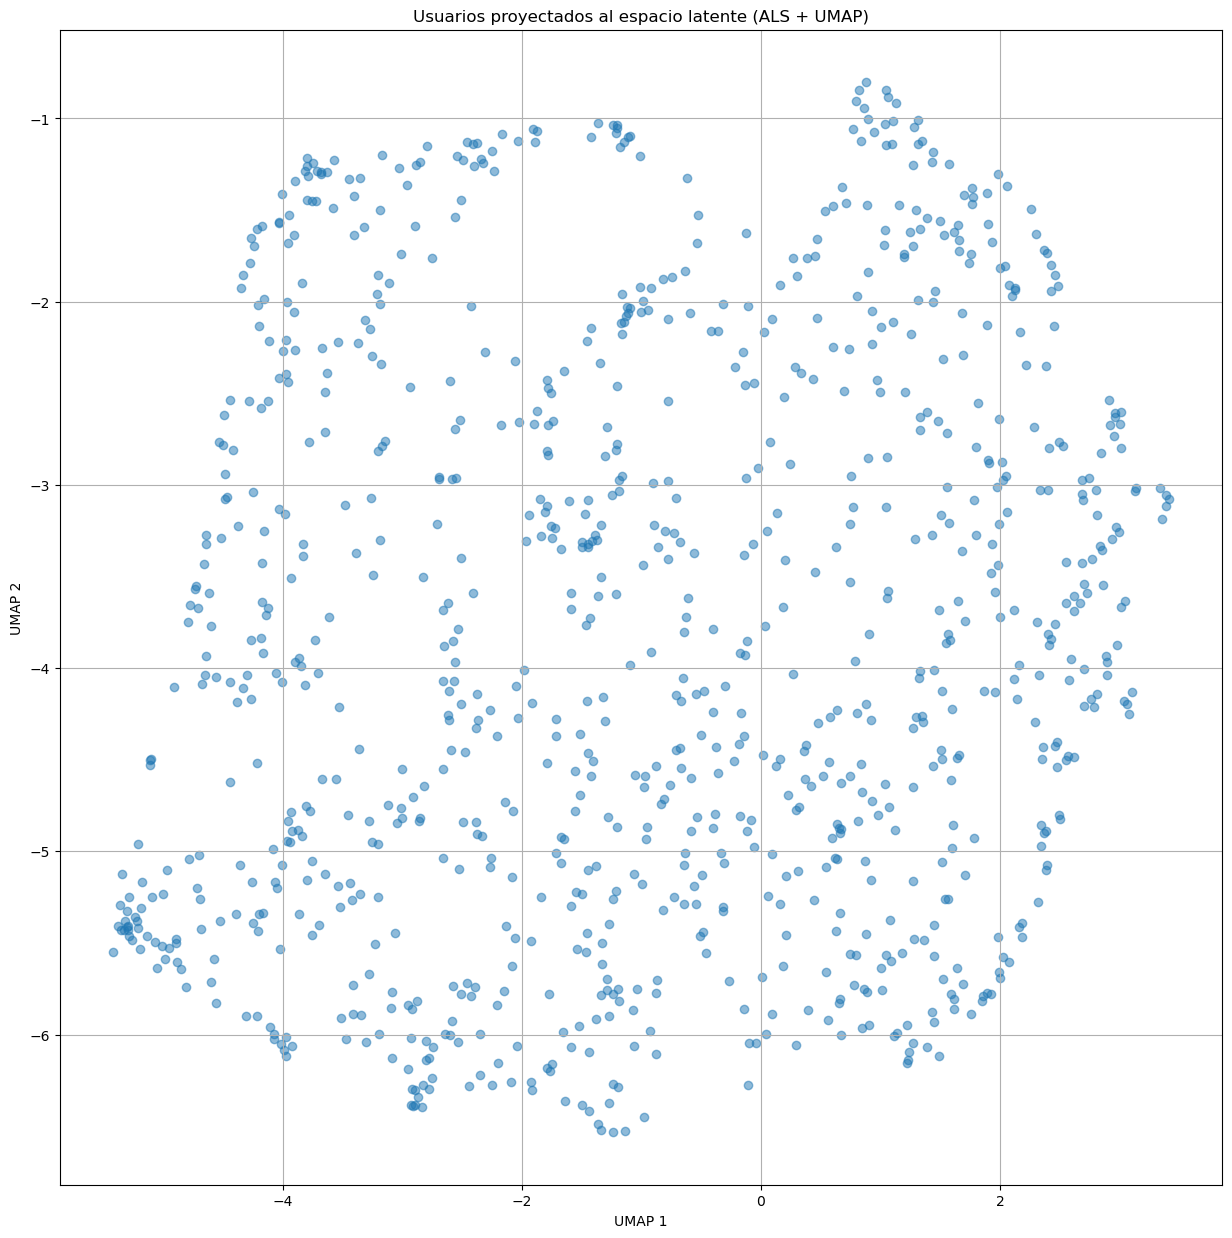

In [19]:
if user_embeddings.shape[1] > 2:
    print("Reduciendo dimensionalidad")
    reducer = umap.UMAP(n_components=2, random_state=seed)
    user_2d = reducer.fit_transform(user_embeddings)
else:
    print("Procediendo sin reducir la dimensionalidad")
    user_2d = user_embeddings

plt.figure(figsize=(15, 15))
plt.scatter(user_2d[:, 0], user_2d[:, 1], alpha=0.5)
plt.title("Usuarios proyectados al espacio latente (ALS + UMAP)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.show()

Reduciendo dimensionalidad


C:\Users\Usuario\anaconda3\envs\env_uoc202402pec2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


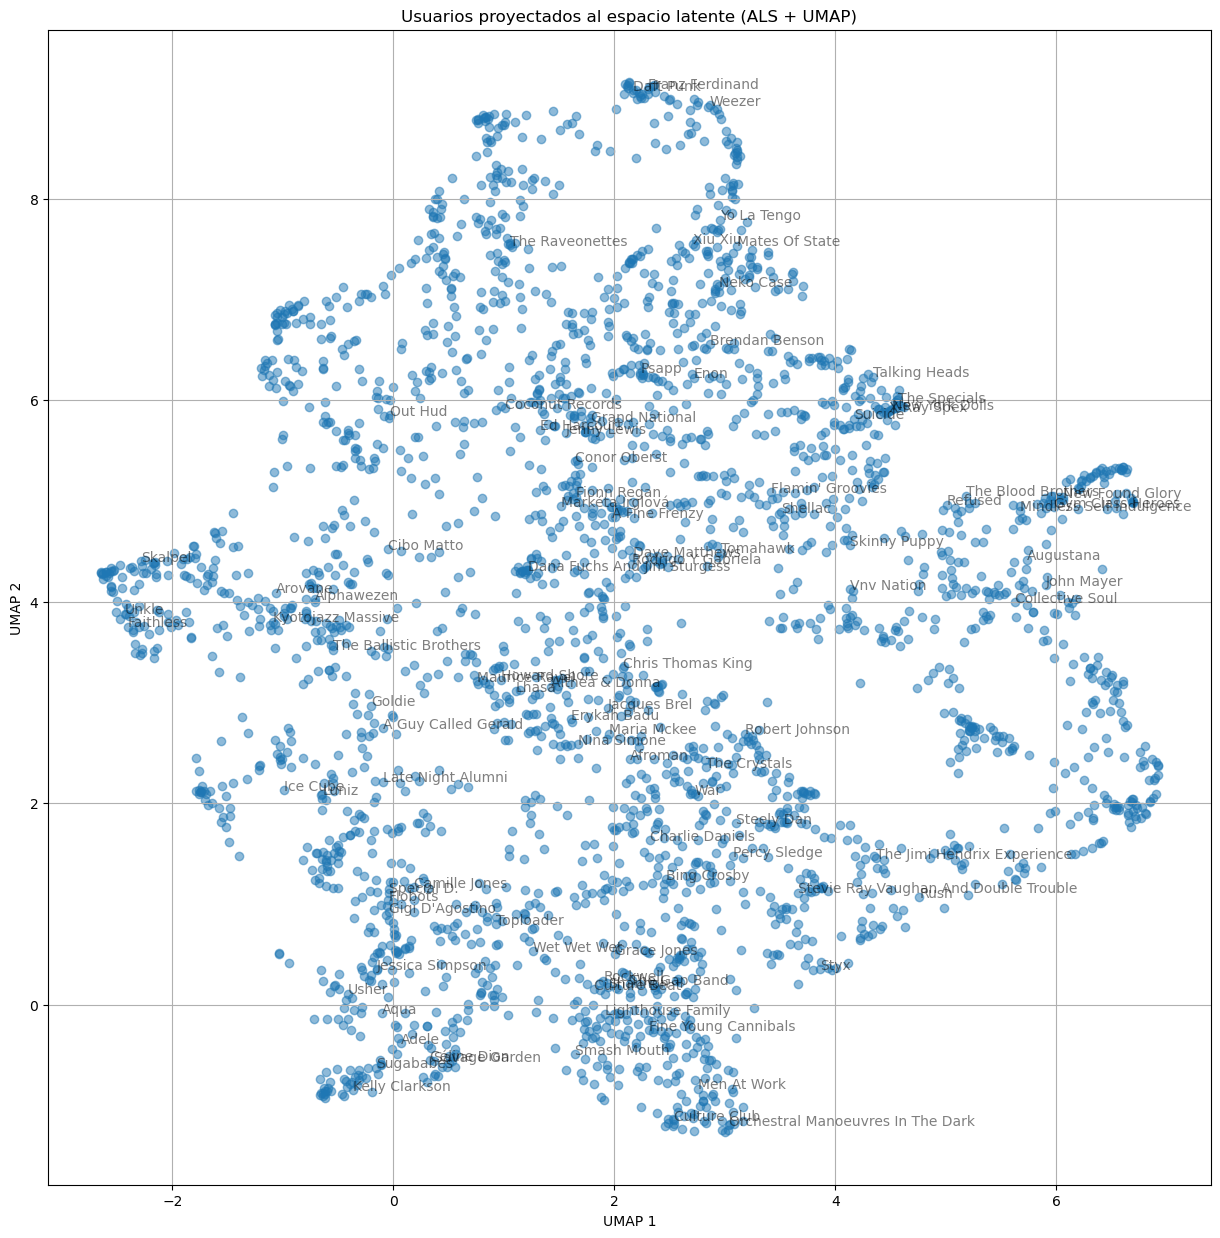

In [20]:
if artist_embeddings.shape[1] > 2:
    print("Reduciendo dimensionalidad")
    reducer = umap.UMAP(n_components=2, random_state=seed)
    artist_2d = reducer.fit_transform(artist_embeddings)
else:
    print("Procediendo sin reducir la dimensionalidad")
    artist_2d = artist_embeddings

sample_idx = random.sample(range(len(artist_2d)), 100)
sample_labels = [idx_to_artist[i] for i in sample_idx]

plt.figure(figsize=(15, 15))
plt.scatter(artist_2d[:, 0], artist_2d[:, 1], alpha=0.5)

for i in sample_idx:
    plt.text(artist_2d[i, 0], artist_2d[i, 1], sample_labels[sample_idx.index(i)], alpha=0.5)
plt.title("Usuarios proyectados al espacio latente (ALS + UMAP)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.show()

## Recomendación de música

<div class="alert alert-block alert-info">
<h4>Recomendación de artistas:</h4>
Ahora que tenemos el modelo usario-artistas entrenado, utilizaremos el método recommend para mostrar el top 10 de recomendaciones para un usuario cualquiera.
</div>


In [21]:
user_idx = seed  # indice del user

# Obtenemos sus artistas más escuchados
user_row = user_artist_matrix[user_idx]
listened_artist_indices = user_row.indices
listened_artists = [idx_to_artist[i] for i in listened_artist_indices]

print("Artistas que ha escuchado el usuario:")
for artist in listened_artists[:10]:  
    print("-", artist)

# Obtenemos las 10 mejores recomendaciones
# Se especifican los parámetros de forma diferente por un cambio de api (fallaba la ejecución)
# https://github.com/benfred/implicit/issues/535
recommendations, scores = ALS_model.recommend(user_idx, user_artist_matrix[user_idx], N=10)

print("\n Recomendaciones para el usuario:")
for idx in range(len(recommendations)):
    print(f"- {idx_to_artist[idx]} (score: {scores[idx]:.3f})")


Artistas que ha escuchado el usuario:
- Red Hot Chili Peppers
- The Go! Team
- The Strokes
- Jet
- Razorlight
- Feist
- Dirty Pretty Things
- Kings Of Convenience
- Hot Hot Heat
- The Boy Least Likely To

 Recomendaciones para el usuario:
- Minus 8 (score: 0.082)
- 4Hero (score: 0.079)
- Röyksopp (score: 0.077)
- Bugge Wesseltoft (score: 0.075)
- Fleet Foxes (score: 0.073)
- Miss Kittin & The Hacker (score: 0.073)
- The Cinematic Orchestra (score: 0.072)
- Björk (score: 0.071)
- Moby (score: 0.070)
- Radiohead (score: 0.069)


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Recomendación de canciones:</strong> Calcularemos el embedding de las canciones y visualizaremos con matpltolib los usuarios en el nuevo espacio latente reducido.
</div>

  0%|          | 0/15 [00:00<?, ?it/s]

Reduciendo dimensionalidad


C:\Users\Usuario\anaconda3\envs\env_uoc202402pec2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


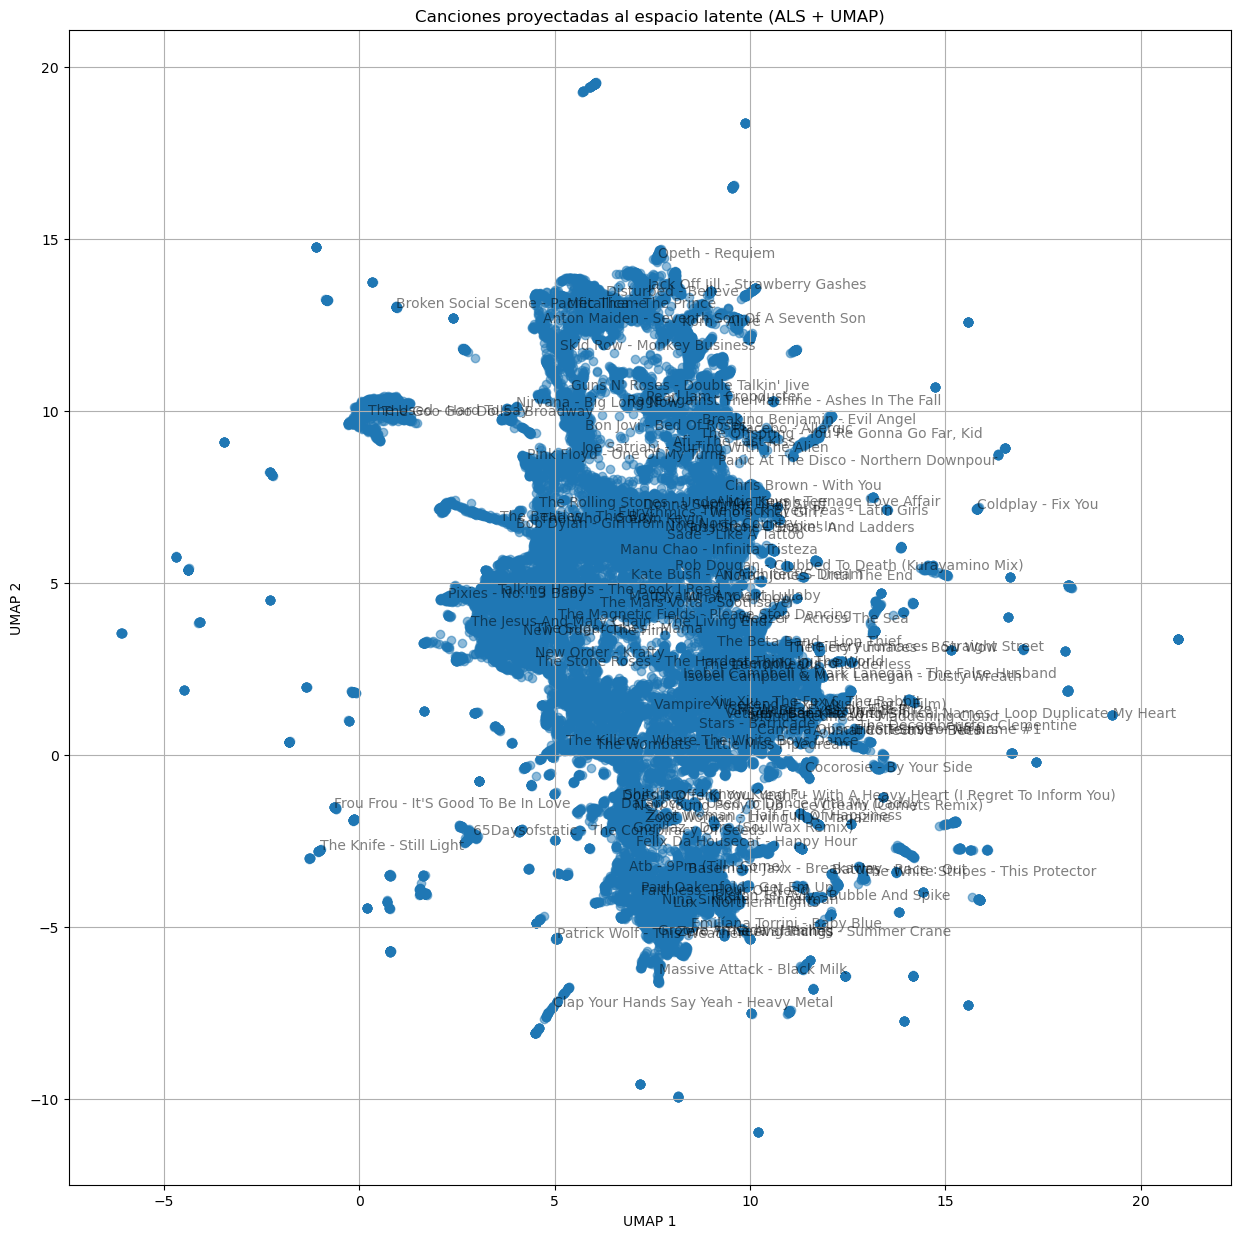

In [22]:
# Seguimos el mismo procedimiento que para los anteriores ejercicios
# Necesario crear el modelo de nuevo
ALS_model = AlternatingLeastSquares(
    factors=12,
    random_state=seed
)
ALS_model.fit(user_song_matrix)
song_embeddings = ALS_model.item_factors # no necesitaremos user_factors

if song_embeddings.shape[1] > 2:
    print("Reduciendo dimensionalidad")
    reducer = umap.UMAP(n_components=2, random_state=seed)
    song_2d = reducer.fit_transform(song_embeddings)
else:
    print("Procediendo sin reducir la dimensionalidad")
    song_2d = song_embeddings

sample_idx = random.sample(range(len(song_2d)), 100)
sample_labels = [idx_to_song[i] for i in sample_idx]

plt.figure(figsize=(15, 15))
plt.scatter(song_2d[:, 0], song_2d[:, 1], alpha=0.5)

for i in sample_idx:
    plt.text(song_2d[i, 0], song_2d[i, 1], sample_labels[sample_idx.index(i)], alpha=0.5)
plt.title("Canciones proyectadas al espacio latente (ALS + UMAP)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.show()

In [23]:
assert len(song_embeddings) == 32790, '# of songs does not match!'

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> En cuanto al enfoque de clustering, en este caso el clustering basado en densidad considero que tiene más sentido. Como nos interesa no predefinir el número de clusters, acepta formas no uniformes de cluster y como hemos visto funciona bien con la reducción de UMAP, aplicaría DBSCAN de nuevo para este clustering. 
</div>